# Code

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt 
import json
import polars as pl
from typing import List, Tuple, Dict, Any

def load_json_data(filepath: str) -> List[Dict]:
    """Load and parse JSON data from runs file."""
    with open(filepath, 'r') as file:
        content = file.read()
    
    # Split the content into individual JSON strings
    json_strings = content.strip().split('\n}\n')
    
    # Add the missing closing brace to each split string (except the last one)
    json_objects = []
    for i, s in enumerate(json_strings):
        if i < len(json_strings) - 1:
            s += '}'  # Add the closing brace that was split off
        json_objects.append(json.loads(s))
    
    return json_objects


def normalize_latent(obj):
    if isinstance(obj, dict) and "autoencoder" in obj.keys():
        return {'latent_type': 'nonlinear', **obj}  # Keep original fields
    elif isinstance(obj, str):
        return {'latent_type' : obj, 'autoencoder': None, 'id': None}
    else:
        return obj


def create_metrics_df():
    json_objects = load_json_data("data/runs.json")

    # Normalize latents such that polars accepts it
    json_objects = load_json_data("data/runs.json")
    for obj in json_objects:
        if obj["gvf"] is None:
            continue
        obj["gvf"]["latent"] = normalize_latent(obj["gvf"]["latent"])
    
    df = (pl.DataFrame(json_objects)).select([
        "run_id",
        "num_images",
        pl.col("sampler").struct["apply_2nd_order"],
        pl.col("sampler").struct["num_steps"],
        pl.col("sampler").struct["S_churn"],
        pl.col("sampler").struct["sigma_max"],
        pl.col("generate").struct["example_idx_range"],
        pl.col("gvf").struct["vectorfield"].struct["noise_gate"],
        pl.col("gvf").struct["latent"],
        pl.col("generate").struct["use_noisy_examples"],
        pl.col("metrics")
    ]).unnest(["noise_gate", "latent"])

    return df
    
def print_formatted_table(df: pl.DataFrame):
    """Print dataframe as formatted LaTeX-style table."""
    formatted_rows = []
    for row in df.iter_rows():
        formatted_rows.append("&" + "\t&".join((str(x) for x in row)) + " \\\\")
    
    print("\n".join(formatted_rows))

def substract_baseline(df: pl.DataFrame, df_base: pl.DataFrame):
    assert df_base.shape[0] == 1,\
    f"Expected baseline dataframe to have shape : (1, {df.shape[1]})  , got shape : {df_base.shape}"   
    df = df.with_columns([
        df[col] - df_base[col].item()
        for col in df.columns
        if col != "nu"
    ])
    
    return df
    
def plot_metric(
    df: pl.DataFrame, 
    ax: plt.Axes,
    metrics: List[str],
    df_base : pl.DataFrame = None,
):

    # If baseline dataframe, display difference
    if df_base is not None:
        df = substract_baseline(df, df_base)

    # Plot (nu, metric) for each specified metric
    x = df["nu"]
    for metric in metrics:
        ax.scatter(x, df[metric], label= metric)

    # Stylize axis
    ax.set_axisbelow(True)
    ax.axhline(y=0, c="black", ls="--", alpha=0.5, zorder=1)
    ax.grid(True)
    ax.legend(loc="best")
    ax.set_xscale('log')

def plot_condition(
    fig: plt.Figure,
    axes: plt.Axes,
    df_many: pl.DataFrame, 
    df_few: pl.DataFrame, 
    df_base: pl.DataFrame, 
    title: str,
):

    fig.suptitle(title + r"($n_{\text{images} = 10.000})$", fontsize=16)
    plot_metric(df_many, axes[0], metrics=["fid", "fd_dinov2"], df_base=df_base)
    plot_metric(df_few, axes[1], metrics=["fid", "fd_dinov2"], df_base=df_base)
    axes[0].set_title(f"Image Quality \n" r"$\mu \sim \text{Unif}(C_k)$")
    axes[1].set_title(f"Image Quality \n" r"$\mu = e_k \in C_k$")
    plot_metric(df_many, axes[2], metrics=["fid_csmean", "fd_dinov2_csmean", "clip_csmean"], df_base=df_base)
    plot_metric(df_few, axes[3], metrics=["fid_csmean", "fd_dinov2_csmean", "clip_csmean"], df_base=df_base)
    axes[2].set_title(f"Similarity-To-Template \n" r"$\mu \sim \text{Unif}(C_k)$")
    axes[3].set_title(f"Similarity-To-Template \n" r"$\mu = e_k \in C_k$")



def plot_comparison_samplers(
    df_full,
    conditions,
    metrics,
):
    # Build union of all 'nu' values (force float)
    union_nu_df = (
        pl.concat([df.select(pl.col("nu").cast(pl.Float64)) for df in df_full.values()])
          .unique()
          .sort("nu")
    )
    
    # Iterate through each metric
    n_rows = int(max(pos[0] for pos in metrics.values())) + 1
    n_cols = int(max(pos[1] for pos in metrics.values())) + 1
    fig, axes = plt.subplots(n_rows, n_cols, 
                             figsize=(5.3 * n_cols, 5.3 * n_rows), constrained_layout=True, squeeze=False)
    
    for ax, metric in zip(axes.flat, metrics):
        if isinstance(metrics, dict):
            ax = axes[metrics[metric]]
            
        df_metric = union_nu_df.clone()
        for name, df in df_full.items():
            if not name in conditions:
                continue
            # Select al columns with metric and join
            col = df.select(
                pl.col("nu").cast(pl.Float64), 
                pl.col(metric).alias(f"{name}")
            )
            df_metric = df_metric.join(col, on="nu", how="left")
    
            # Add name
            ax.set_ylabel(metric)
            ax.set_xlabel(r"$\sigma\  (noise)$")
            
            
            # Filter nu under certain value 
            #df_metric = df_metric.filter(pl.col("nu") > 10**-1/2)
        plot_metric(df_metric, ax, metrics=df_metric.columns[1:])

    return fig, axes

# Import all runs and baseline

In [2]:
df_all = create_metrics_df()
df_base = {}
df_many = {}
df_few = {}
df_all

run_id,num_images,apply_2nd_order,num_steps,S_churn,sigma_max,example_idx_range,type_gate,decay_rate,nu,noise_onset,latent_type,autoencoder,id,use_noisy_examples,metrics
i64,i64,bool,i64,f64,i64,list[i64],str,f64,f64,f64,str,str,str,bool,struct[6]
1,10000,true,32,0.0,80,null,"""quadratic""",null,6.5,80.0,"""nonlinear""","""kl""","""stabilityai/sd-turbo""",null,"{28.089861,263.327682,0.646231,0.34375,0.763354,null}"
2,50000,true,32,0.0,80,null,null,null,null,null,null,null,null,null,"{2.387396,113.867092,0.656316,0.339177,0.769866,null}"
3,10000,true,32,0.0,80,null,"""quadratic""",null,6.5,31.21,"""nonlinear""","""kl""","""stabilityai/sd-turbo""",null,"{26.189643,253.67704,0.644845,0.337578,0.762956,null}"
4,10000,true,32,0.0,80,null,"""quadratic""",null,31.21,80.0,"""nonlinear""","""kl""","""stabilityai/sd-turbo""",null,"{9.826316,154.597507,0.654993,0.355583,0.770913,null}"
5,10000,true,32,0.0,80,null,"""quadratic""",null,8.28,80.0,"""nonlinear""","""kl""","""stabilityai/sd-turbo""",null,"{29.168356,270.218816,0.638487,0.331863,0.759655,null}"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
222,10000,true,32,40.0,80,null,"""heaviside""",null,0.5977,80.0,"""ambient""",null,null,false,"{13.86328,183.845509,0.769232,0.523419,0.82985,36.936325}"
223,10000,true,32,40.0,80,"[0, 1]","""heaviside""",null,80.0,80.0,"""ambient""",null,null,false,"{4.972998,136.978022,0.656113,0.351414,0.774234,41.318935}"
224,10000,true,32,40.0,80,"[0, 1]","""heaviside""",null,55.73621,80.0,"""ambient""",null,null,false,"{4.803945,134.234898,0.656603,0.354981,0.774425,41.105827}"


# Example-Guided Determinstic 2nd-Order

(-0.05, 0.25)

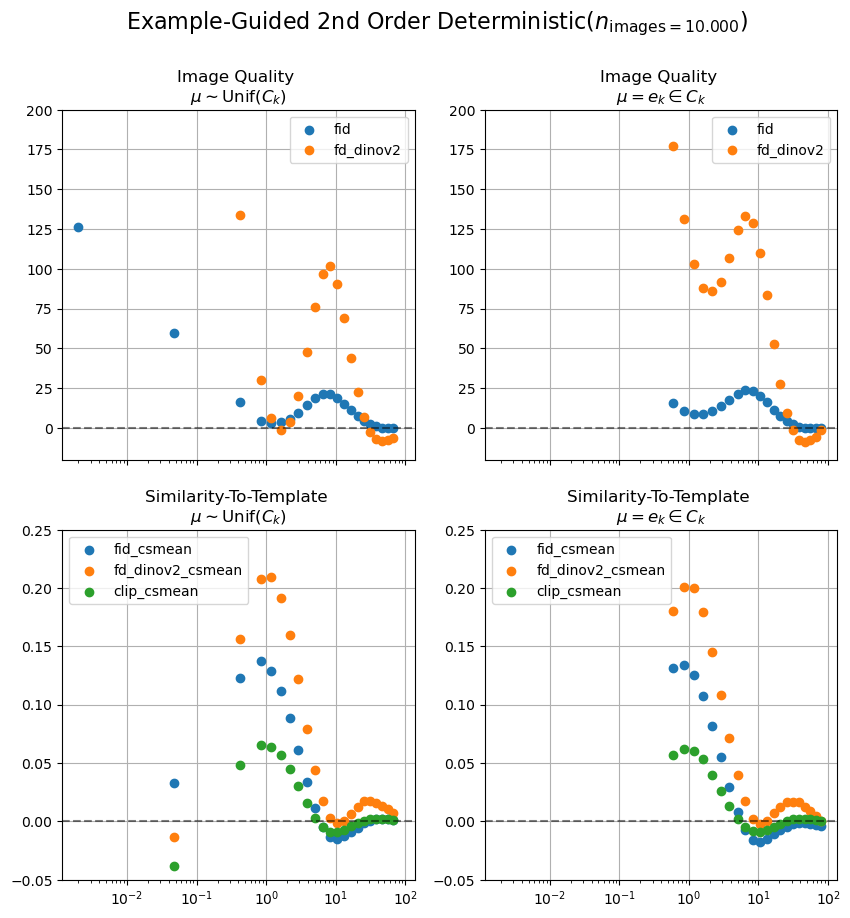

In [3]:
name = "lat-det-2ndord"
df_base[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    pl.col("S_churn")           == 0, 
]).select(["nu", "metrics"]).unnest("metrics")


df_many[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Latent space 
    pl.col("autoencoder")       == "kl",
    pl.col("id")                == "stabilityai/sd-turbo",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Few-Examples
    pl.col("example_idx_range").is_null(),
    # Deterministic
    pl.col("S_churn")           == 0,
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")

df_few[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Latent space 
    pl.col("autoencoder")       == "kl",
    pl.col("id")                == "stabilityai/sd-turbo",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Few-Examples
    pl.col("example_idx_range") == [0, 1],
    # Deterministic
    pl.col("S_churn")           == 0,
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")


# Ensure you have no duplicates of nu 
assert df_many[name]["nu"].is_unique().all() == True
assert df_few[name]["nu"].is_unique().all() == True

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True)
plot_condition(fig, axes.flat, df_many[name], df_few[name], df_base[name], title="Example-Guided 2nd Order Deterministic")
axes[0,1].set_ylim([-20, 200])
axes[0,0].set_ylim([-20, 200])
axes[1,1].set_ylim([-0.05, 0.25])
axes[1,0].set_ylim([-0.05, 0.25])

# Example-Guided Stochastic 1st-Order

(-0.05, 0.25)

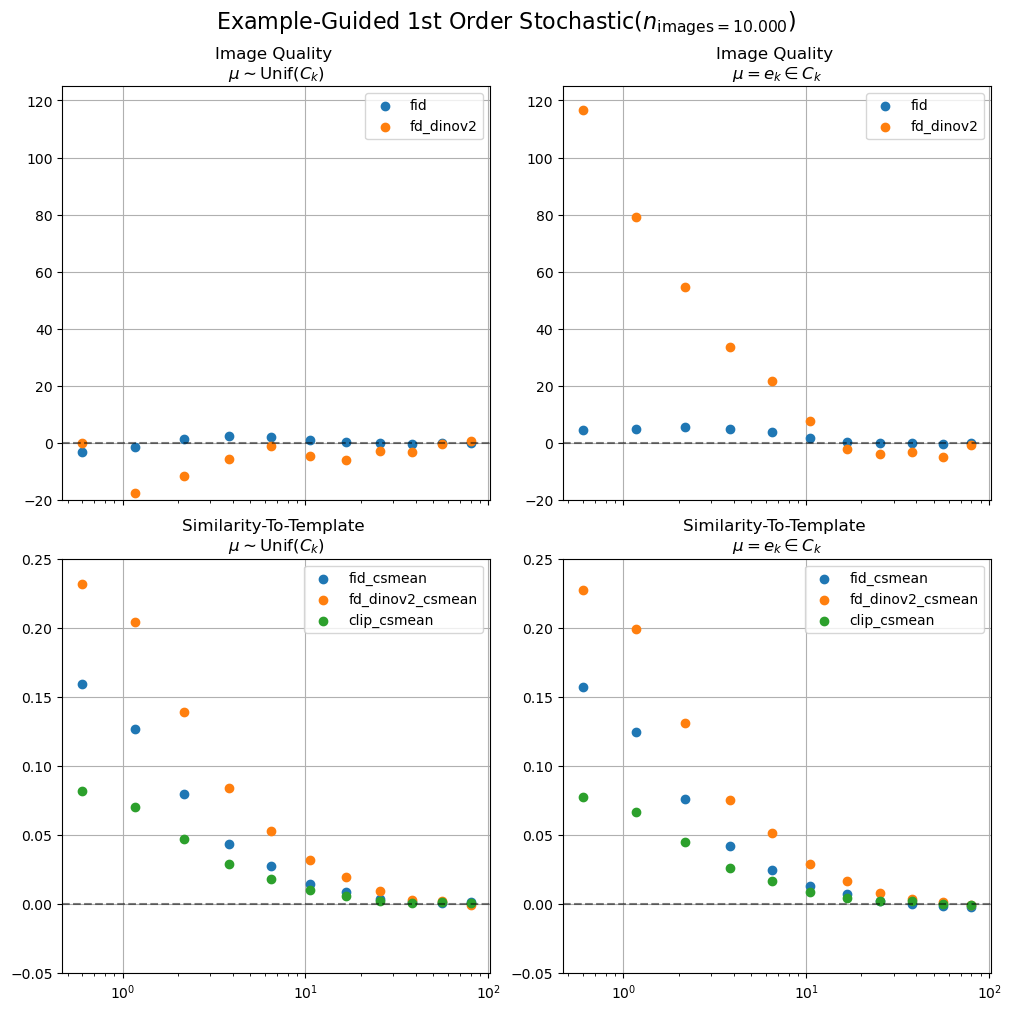

In [4]:
name = "lat-stoch-1stord"
df_base[name] = df_all.filter([
    # 1st Order Sampling 
    pl.col("apply_2nd_order")   == False,
    pl.col("num_steps")         == 64,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
    # Sigma max at 80 
    pl.col("sigma_max")         == 80,
]).select(["nu", "metrics"]).unnest("metrics")


df_many[name] = df_all.filter([
    # 1st Order Sampling 
    pl.col("apply_2nd_order")   == False,
    pl.col("num_steps")         == 64,
    # Latent space 
    pl.col("autoencoder")       == "kl",
    pl.col("id")                == "stabilityai/sd-turbo",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")

df_few[name] = df_all.filter([
    # 1st Order Sampling 
    pl.col("apply_2nd_order")   == False,
    pl.col("num_steps")         == 64,
    # Latent space 
    pl.col("autoencoder")       == "kl",
    pl.col("id")                == "stabilityai/sd-turbo",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Few-Examples
    pl.col("example_idx_range") == [0, 1],
    # Stochastic
    pl.col("S_churn")           != 0,
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")


# Assert df_base is a single file
assert df_base[name].shape[0] == 1
# Ensure you have no duplicates of nu 
assert df_many[name]["nu"].is_unique().all() == True
assert df_few[name]["nu"].is_unique().all() == True

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True, sharex=True)
plot_condition(fig, axes.flat, df_many[name], df_few[name], df_base[name], title="Example-Guided 1st Order Stochastic")
axes[0,1].set_ylim([-20, 125])
axes[0,0].set_ylim([-20, 125])
axes[1,1].set_ylim([-0.05, 0.25])
axes[1,0].set_ylim([-0.05, 0.25])


# Example-Guided Stochastic 2nd-Order

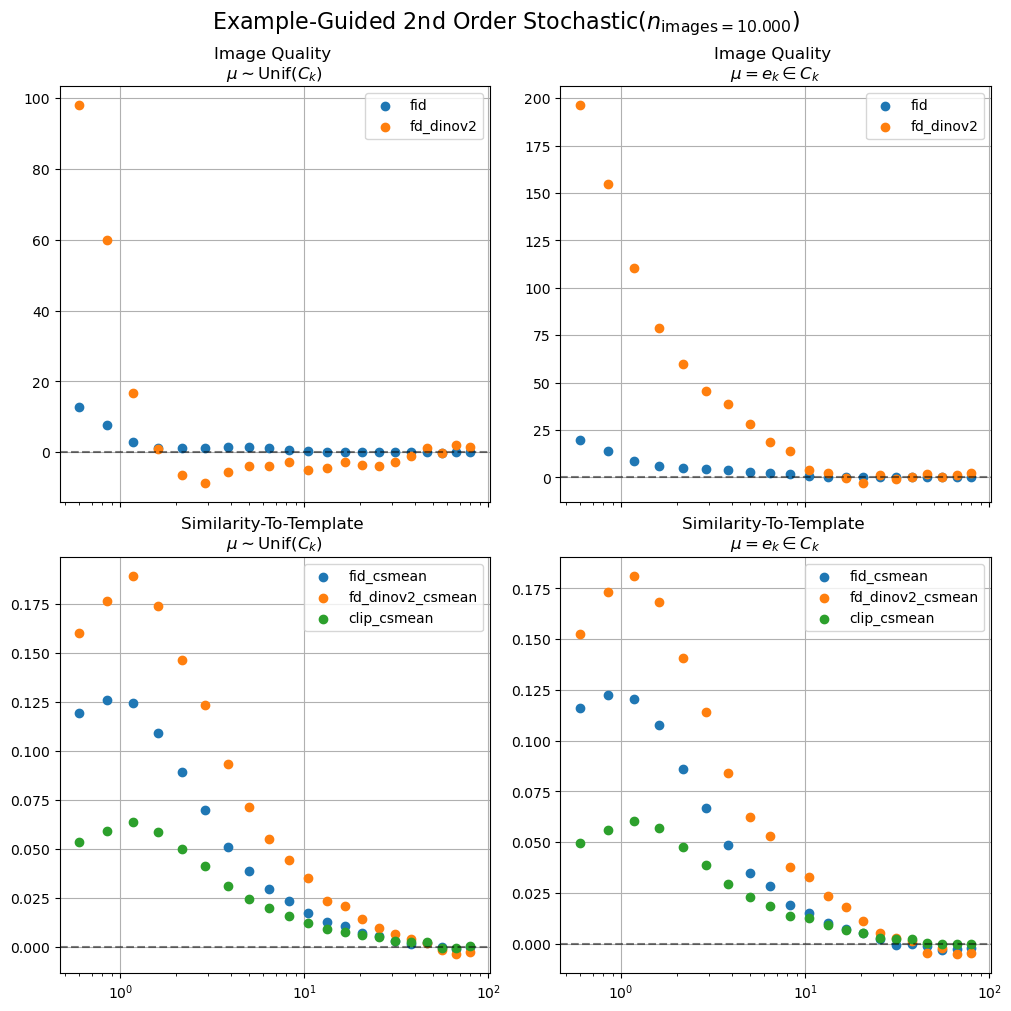

In [5]:
name = "lat-stoch-2ndord"
df_base[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
    # Sigma max at 80 
    pl.col("sigma_max")         == 80,
]).select(["nu", "metrics"]).unnest("metrics")


df_many[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Latent space 
    pl.col("autoencoder")       == "kl",
    pl.col("id")                == "stabilityai/sd-turbo",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")

df_few[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Latent space 
    pl.col("autoencoder")       == "kl",
    pl.col("id")                == "stabilityai/sd-turbo",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    # Few-Examples
    pl.col("example_idx_range") == [0, 1],
    # Stochastic
    pl.col("S_churn")           != 0,
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")


# Assert df_base is a single file
assert df_base[name].shape[0] == 1, f"Expected (1, ...) got {df_base[name].shape}"
# Ensure you have no duplicates of nu 
assert df_many[name]["nu"].is_unique().all() == True
assert df_few[name]["nu"].is_unique().all() == True

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True, sharex=True)
plot_condition(fig, axes.flat, df_many[name], df_few[name], df_base[name], title="Example-Guided 2nd Order Stochastic")




# Pixel-Guided 2nd-Order Stochastic

(-0.05, 0.25)

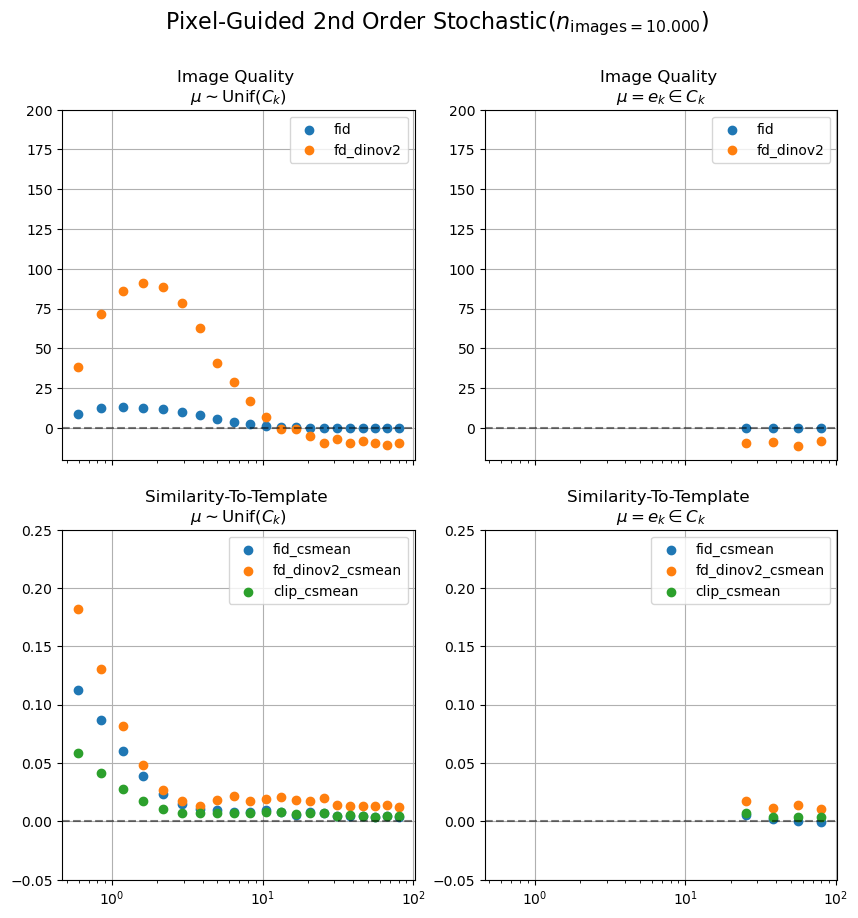

In [19]:
name = "pix-stoch-2ndord"

df_base[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    pl.col("S_churn")           == 0,
]).select(["nu", "metrics"]).unnest("metrics")

df_many[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Ambient space
    pl.col("latent_type")       == "ambient",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    pl.col("use_noisy_examples")== False,
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0,
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")


df_few[name] = df_all.filter([
    # 2nd Order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Ambient space
    pl.col("latent_type")       == "ambient",
    # Heaviside noise gate
    pl.col("type_gate")         == "heaviside",
    # No delayed guidance initialization
    pl.col("noise_onset")       == 80.0,
    pl.col("use_noisy_examples")== False,
    # Many-Examples
    pl.col("example_idx_range") == [0, 1],
    # Stochastic
    pl.col("S_churn")           != 0,
]).select(["nu", "metrics"]).sort("nu").unnest("metrics")


# Ensure you have no duplicates of nu 
assert df_many[name]["nu"].is_unique().all() == True
assert df_few[name]["nu"].is_unique().all() == True

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True)
plot_condition(fig, axes.flat, df_many[name], df_few[name], df_base[name], title="Pixel-Guided 2nd Order Stochastic")
axes[0,1].set_ylim([-20, 200])
axes[0,0].set_ylim([-20, 200])
axes[1,1].set_ylim([-0.05, 0.25])
axes[1,0].set_ylim([-0.05, 0.25])

# SDEdit Stochastic 1st-Order

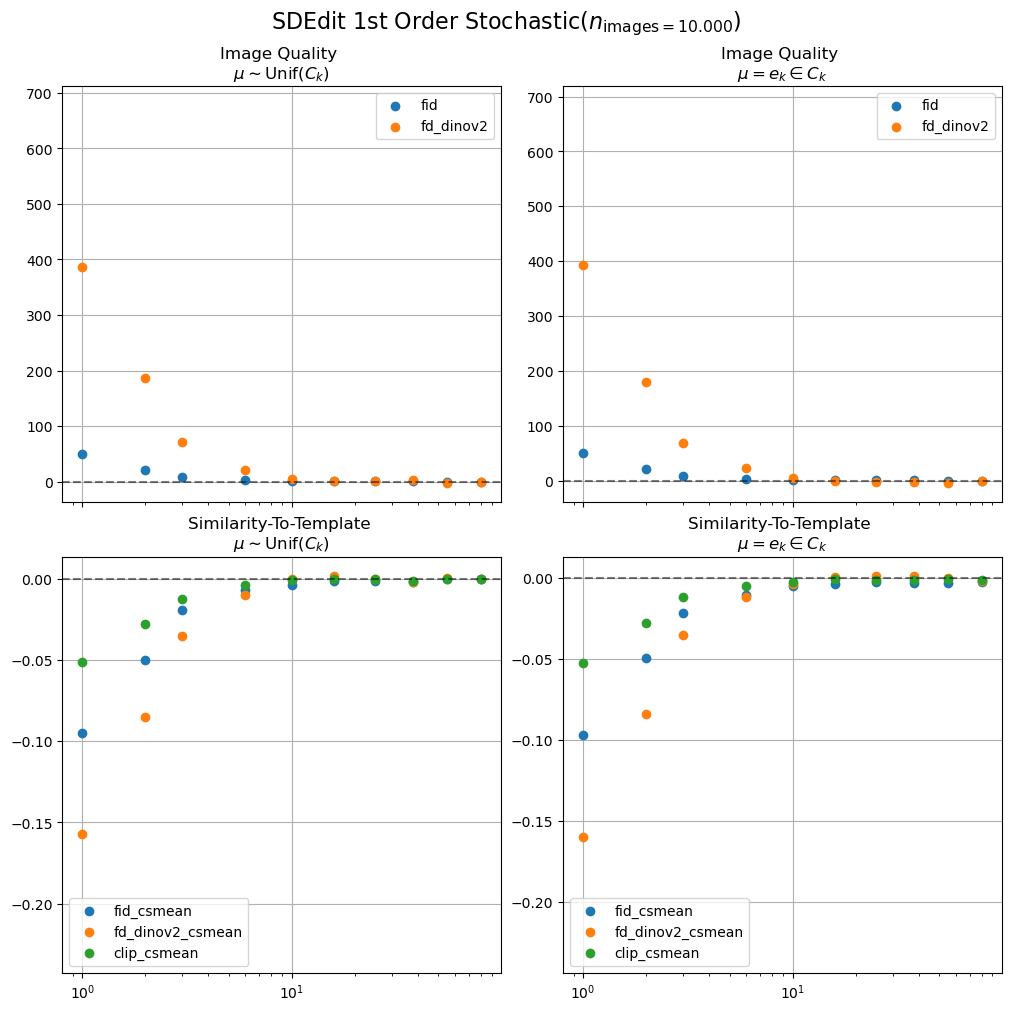

In [7]:
name = "sdedit-stoch-1stord"
df_base[name] = df_all.filter([
    # 1st Order Sampling 
    pl.col("apply_2nd_order")   == False,
    pl.col("num_steps")         == 64,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
    # Sigma max at 80 
    pl.col("sigma_max")         == 80,
]).select(["sigma_max", "metrics"]).sort("sigma_max").unnest("metrics")

df_many[name] = df_all.filter([
    # 1st Order Sampling 
    pl.col("apply_2nd_order")   == False,
    pl.col("num_steps")         == 64,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Use noisy examples
    pl.col("use_noisy_examples")==True,
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
]).select(["sigma_max", "metrics"]).sort("sigma_max").unnest("metrics")


df_few[name] = df_all.filter([
    # 1st Order Sampling 
    pl.col("apply_2nd_order")   == False,
    pl.col("num_steps")         == 64,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Use noisy examples
    pl.col("use_noisy_examples")==True,
    # Many-Examples
    pl.col("example_idx_range") == [0,1],
    # Stochastic
    pl.col("S_churn")           != 0, 
]).select(["sigma_max", "metrics"]).sort("sigma_max").unnest("metrics")



# Ensure you have no duplicates of nu 
assert df_many[name]["sigma_max"].is_unique().all() == True
assert df_few[name]["sigma_max"].is_unique().all() == True

# Rename 
df_base[name] = df_base[name].rename({"sigma_max": "nu"})
df_many[name] = df_many[name].rename({"sigma_max": "nu"})
df_few[name] = df_few[name].rename({"sigma_max": "nu"})


fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True, sharex=True)
plot_condition(fig, axes.flat, df_many[name], df_few[name], df_base[name], title="SDEdit 1st Order Stochastic")


# SDEdit Stochastic 2nd-Order

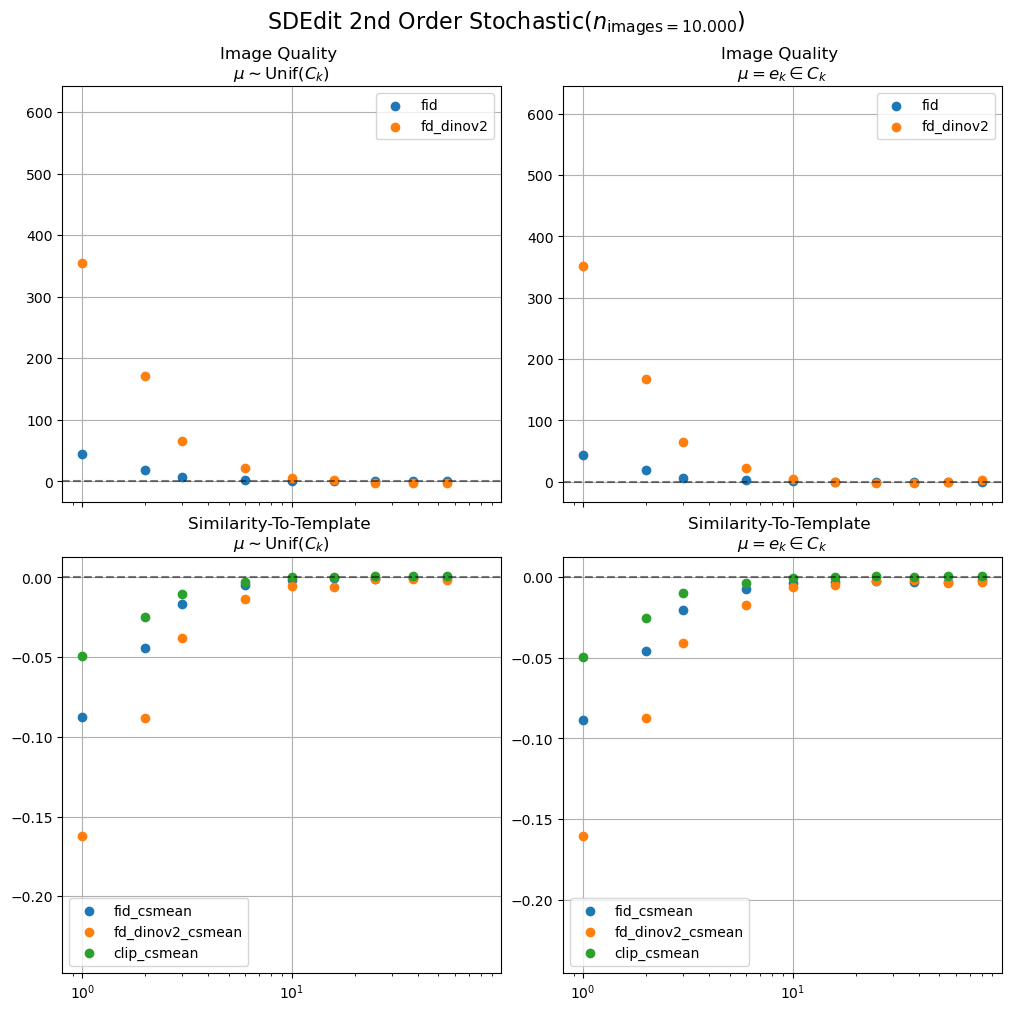

In [8]:
name = "sdedit-stoch-2ndord"
df_base[name] = df_all.filter([
    # 2nd order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
    # Sigma max at 80 
    pl.col("sigma_max")         == 80,
]).select(["sigma_max", "metrics"]).sort("sigma_max").unnest("metrics")

df_many[name] = df_all.filter([
    # 2nd order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Use noisy examples
    pl.col("use_noisy_examples")==True,
    # Many-Examples
    pl.col("example_idx_range").is_null(),
    # Stochastic
    pl.col("S_churn")           != 0, 
]).select(["sigma_max", "metrics"]).sort("sigma_max").unnest("metrics")


df_few[name] = df_all.filter([
    # 2nd order Sampling 
    pl.col("apply_2nd_order")   == True,
    pl.col("num_steps")         == 32,
    # Num steps = 10_000
    pl.col("num_images")        == 10_000,
    # No noise gate
    pl.col("type_gate").is_null(),
    pl.col("nu").is_null(),
    # Use noisy examples
    pl.col("use_noisy_examples")==True,
    # Many-Examples
    pl.col("example_idx_range") == [0,1],
    # Stochastic
    pl.col("S_churn")           != 0, 
]).select(["sigma_max", "metrics"]).sort("sigma_max").unnest("metrics")



# Ensure you have no duplicates of nu 
assert df_many[name]["sigma_max"].is_unique().all() == True
assert df_few[name]["sigma_max"].is_unique().all() == True

# Rename 
df_base[name] = df_base[name].rename({"sigma_max": "nu"})
df_many[name] = df_many[name].rename({"sigma_max": "nu"})
df_few[name] = df_few[name].rename({"sigma_max": "nu"})


fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True, sharex=True)
plot_condition(fig, axes.flat, df_many[name], df_few[name], df_base[name], title="SDEdit 2nd Order Stochastic")


# Comparison Of Samplers

TypeError: '>' not supported between instances of 'float' and 'NoneType'

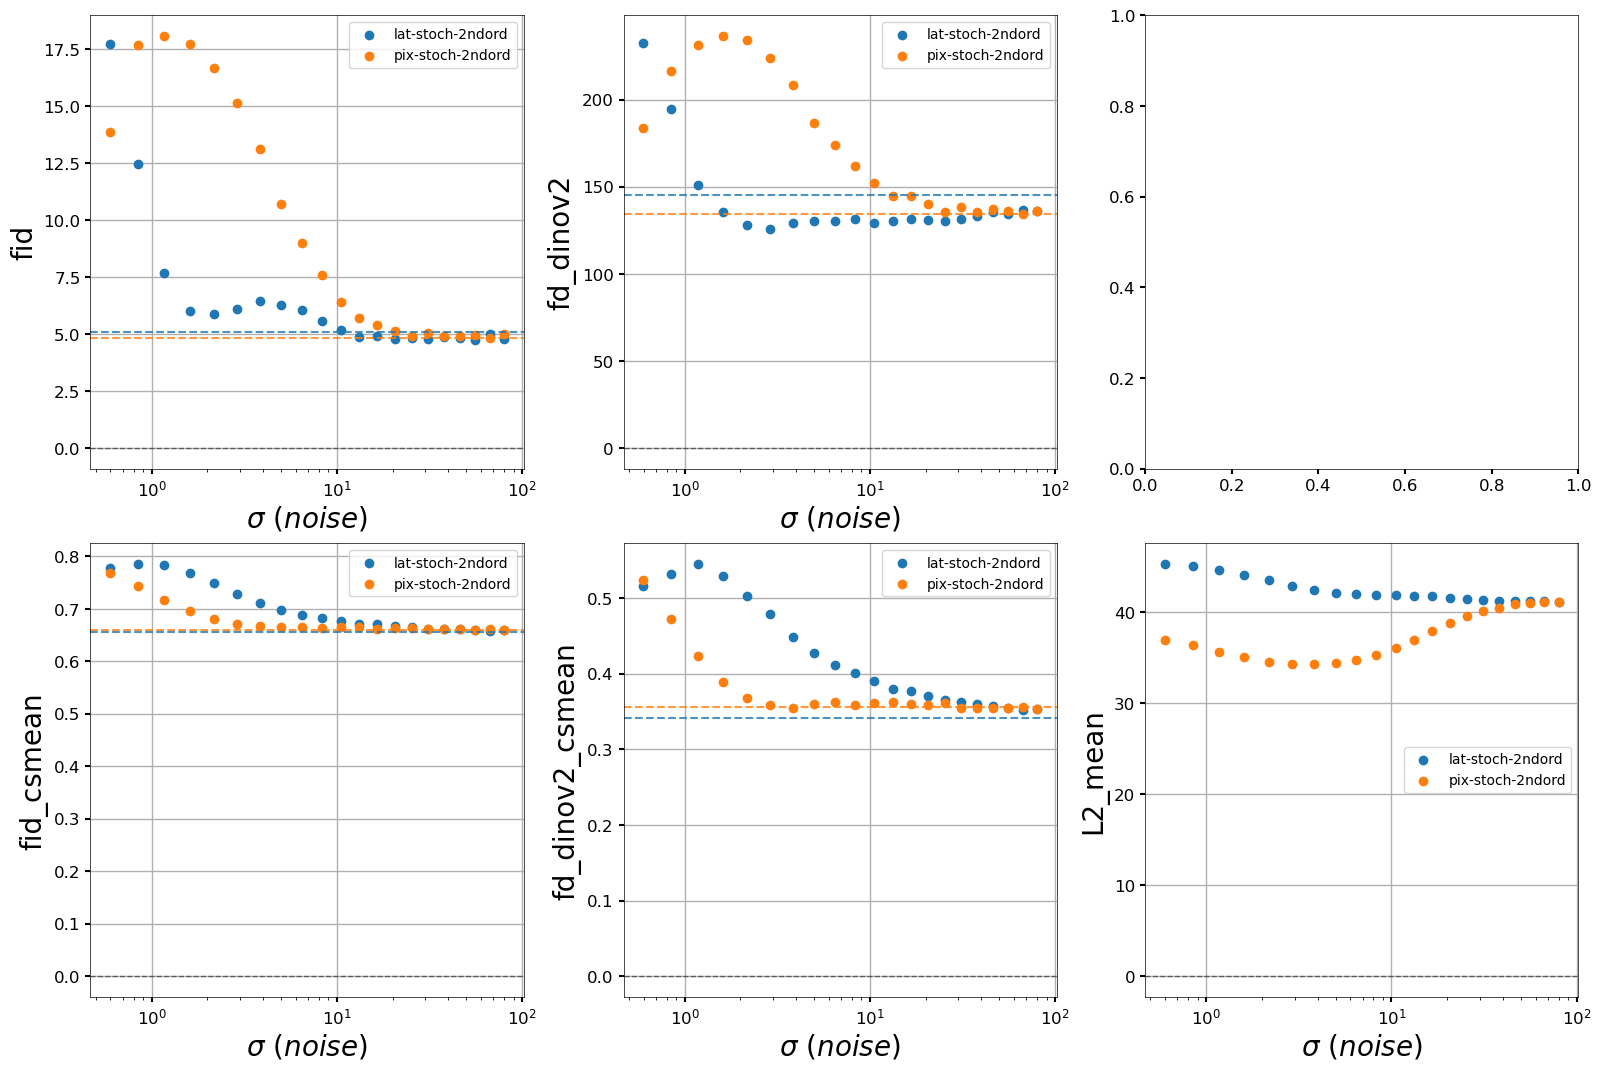

In [26]:

conditions = ["pix-stoch-2ndord", "lat-stoch-2ndord"]
colors=["blue"]
metrics = ["fid", "fd_dinov2", "fid_csmean", "fd_dinov2_csmean", "clip_csmean"]
# Add memorization metrics
if False: 
    for condition in conditions:
        for metric in ["fid", "fd_dinov2"]:
            few_minus_many = df_many[condition].join(df_few[condition], on="nu", suffix="_few").select([
                pl.col("nu"),
                (pl.col(f"{metric}_few") - pl.col(metric)).alias(f"{metric}_mem")
            ])
    
            # Drop the column if it already exists before joining
            if f"{metric}_mem" in df_many[condition].columns:
                df_many[condition] = df_many[condition].drop(f"{metric}_mem")
    
            df_many[condition] = df_many[condition].join(few_minus_many, on="nu")

# Plot comparison 

metrics_pos = {
    "fid" : (0, 0), 
    "fd_dinov2" : (0, 1), 
    "fid_csmean" : (1, 0),
    "fd_dinov2_csmean" : (1, 1),
    "L2_mean" : (1, 2),
    #"clip_csmean" : (0, 2)
    #"fid_mem" : (0, 0), 
    #"fd_dinov2_mem" : (0, 1),
    
}

pub_style = {
    #"font.family": "serif",
    #"font.size": 10,
    "axes.labelsize": 20,
    "axes.titlesize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "grid.linewidth": 1.0,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
}


with plt.rc_context(pub_style):
    fig, axes = plot_comparison_samplers(df_many, conditions, metrics=metrics_pos)
    
if True:      
    cmap = plt.get_cmap('tab10')  
    condition_colors = [cmap(i) for i in range(len(conditions))]
    for metric, pos in metrics_pos.items():
        for condition, color in zip(conditions, condition_colors):
            axes[pos].axhline(df_base[condition][metric].item(), 
                              linestyle="--", alpha=0.8, color=color)

if False:
    for metric, pos in metrics_pos.items():
        for condition in conditions:
            nus = df_many[condition]["nu"]
            vals = df_many[condition][metric]
            
            minima = []
            maxima = []
             
             # Check left edge (first element)
            if len(vals) > 1 and vals[0] < vals[1]:
                minima.append(nus[0])
            elif len(vals) > 1 and vals[0] > vals[1]:
                maxima.append(nus[0])
            
            # Check middle elements
            for i in range(1, len(vals) - 1):
                if vals[i] < vals[i+1] and vals[i] < vals[i-1]:
                    minima.append(nus[i])
                elif vals[i] > vals[i+1] and vals[i] > vals[i-1]:
                    maxima.append(nus[i])
            
            # Check right edge (last element)
            if len(vals) > 1 and vals[-1] < vals[-2]:
                minima.append(nus[-1])
            elif len(vals) > 1 and vals[-1] > vals[-2]:
                maxima.append(nus[-1])
            
            axes[pos].scatter(maxima, len(maxima) * [0])
            axes[pos].scatter(minima, len(minima) * [0])

In [ ]:
savedir = "/home/brachi/slides-ppg/images"
name = "results_memorization_0.pdf"
#fig.savefig(os.path.join(savedir,name), bbox_inches="tight", pad_inches=0.02)
